In [1]:
import pygmt
import numpy as np
import os
import pandas as pd
from pyrocko import util, model, io, trace, gmtpy
import pyrocko.moment_tensor as pmt
from pyrocko.plot import beachball
import matplotlib.pyplot as plt

workdir='../'
catdir =  os.path.join(workdir,'CAT') 

#filename_old= os.path.join(catdir,'catalogue_flegrei_MT_VLP_reloc.pf')                      ###CHANGE###
filename_new= os.path.join(catdir,'catalogue_flegrei_composite_MT_LF_std_reloc_best.pf')    ###CHANGE###
           
#events_old = model.load_events(filename_old)
events_new = model.load_events(filename_new)

#mt_old =[]
#for ev in events_old:
#    mt_old.append( ev.moment_tensor )

mt_new = {}
for ev in events_new:
    mt_new[ev.name] = ev.moment_tensor

In [ ]:
flipped_ev_new= [
'flegrei_2018_09_18_21_36_41',
'flegrei_2023_09_07_17_45_28'
'flegrei_2023_10_02_20_08_26',
'flegrei_2024_06_08_01_52_04',
'flegrei_2024_08_30_19_23_15',
'flegrei_2025_03_14_18_44_10',
'flegrei_2025_03_13_00_25_02',
]

mt=[]
mt_flip=[]
mt_normal=[]
mt_fuzzy=[]

for evname in mt_new:
    
    if evname in flipped_ev_new:
        mt_flip.append( [mt_new[evname],evname] )
    else:
        mt_normal.append( [mt_new[evname],evname] )
mt.append(mt_normal)
mt.append(mt_flip)

for mt_ev in mt_normal:
    mt_fuzzy.append( mt_ev[0] )
for mt_ev in mt_flip: # flip polarity
    mt_flipped = pmt.MomentTensor(m= -1 * mt_ev[0]._m)
    mt_fuzzy.append( mt_flipped )

Plotted beachball 1: flegrei_2023_06_11_06_44_25. Polarity= 1
Plotted beachball 2: flegrei_2023_09_07_17_45_28. Polarity= 1
Plotted beachball 3: flegrei_2023_09_26_07_10_29. Polarity= 1
Plotted beachball 4: flegrei_2023_10_02_20_08_26. Polarity= 1
Plotted beachball 5: flegrei_2024_04_27_03_44_56. Polarity= 1
Plotted beachball 6: flegrei_2024_05_22_06_28_00. Polarity= 1
Plotted beachball 7: flegrei_2024_06_18_01_58_24. Polarity= 1
Plotted beachball 8: flegrei_2024_07_26_11_46_21. Polarity= 1
Plotted beachball 9: flegrei_2025_02_16_14_30_02. Polarity= 1
Plotted beachball 10: flegrei_2018_09_18_21_36_41. Polarity= -1
Plotted beachball 11: flegrei_2024_06_08_01_52_04. Polarity= -1
Plotted beachball 12: flegrei_2024_08_30_19_23_15. Polarity= -1
Plotted beachball 13: flegrei_2025_03_13_00_25_02. Polarity= -1
Plotted beachball 14: flegrei_2025_03_14_18_44_10. Polarity= -1


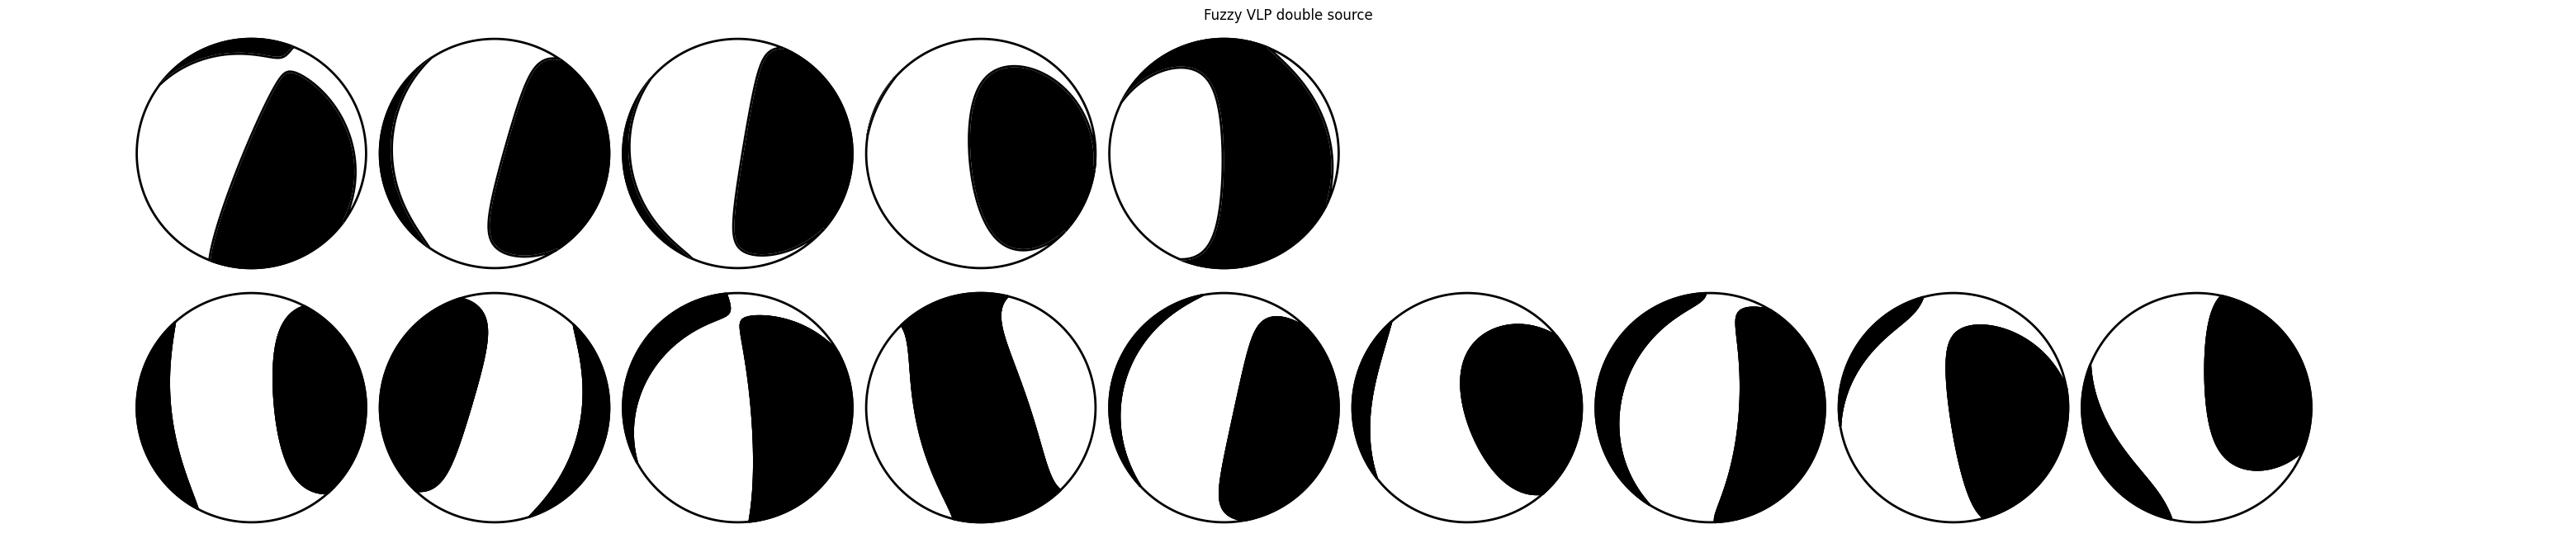

In [3]:
fig = plt.figure(figsize=(40., 8.))
#fig.subplots_adjust(left=0., right=1., bottom=0., top=1.)
axes = fig.add_subplot(1, 1, 1)
axes.set_xlim(0., 4.)
axes.set_ylim(0., 4.)
axes.set_axis_off()
axes.set_title(f'Fuzzy VLP double source')

mt_type = 'deviatoric'          #CHANGE

count_total=0
for i in range(len(mt)):
    if i==0: # normal polarity   
        color_t = 'black'
        color_p = 'white'
    elif i==1: # flipped polarity
        color_t = 'white'
        color_p = 'black'
    else:
        print('ERROR: more than 2 polarities found. Check the code.')
    count_ensamble = 1
    for moment_tensor in mt[i]:
        plot_kwargs = {
            'beachball_type': mt_type,
            'size': 200,
            'position': ( (count_ensamble)*0.38  , ((i+1) * 2.) -1),
            'color_t':color_t,
            'color_p':color_p,
            'edgecolor': 'black',
            'linewidth':2,
            }
        beachball.plot_beachball_mpl(moment_tensor[0],
                                    axes,
                                    **plot_kwargs
                                    )
        print(f'Plotted beachball {count_total+1}: {moment_tensor[1]}. Polarity= {(-1)**i}')

        count_total+=1
        count_ensamble+=1
    

# save
fig.savefig(f'../PLOTS/FOCAL_SPHERE/VLP_mts_{mt_type}.pdf')

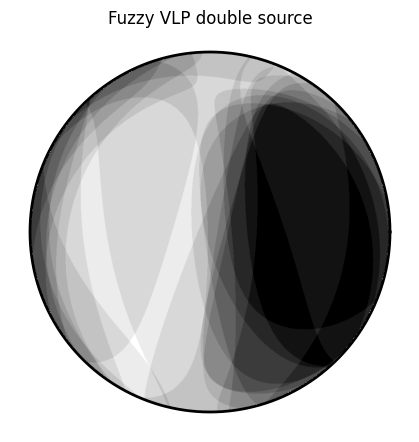

In [7]:
fig = plt.figure(figsize=(4., 4.))
fig.subplots_adjust(left=0., right=1., bottom=0., top=1.)
axes = fig.add_subplot(1, 1, 1)

mt_type='deviatoric'          #CHANGE

# normal polarity
color_t='black'
color_p='white'

plot_kwargs = {
    'beachball_type': mt_type,
    'size': 9,
    'position': (5, 5),
    'color_t':color_t,
    'color_p':color_p,
    'edgecolor': 'black',
    'best_color':'black',
    'linewidth':2, 
    'grid_resolution':800
    }

beachball.plot_fuzzy_beachball_mpl_pixmap(mt_fuzzy, axes, **plot_kwargs)
axes.set_xlim(0., 10.)
axes.set_ylim(0., 10.)
axes.set_axis_off()

axes.set_title(f'Fuzzy VLP double source')

# save
fig.savefig(f'../PLOTS/FOCAL_SPHERE/VLP_fuzzy_{mt_type}.pdf')


# Percentage of DC component

In [5]:
cat_filename=os.path.join(catdir,'catalogue_flegrei_composite_MT_LF_std_reloc_best.pf')
cat=model.load_events(cat_filename)

nonDC=[]
count_ev=0
percentage=0
mag=[]
for ev in cat:
    decomposition=ev.moment_tensor.standard_decomposition()
    (moment_iso, ratio_iso, m_iso)=decomposition[0]
    (moment_dc, ratio_dc, m_dc)=decomposition[1]
    (moment_clvd, ratio_clvd, m_clvd)=decomposition[2]
    (moment_devi, ratio_devi, m_devi)=decomposition[3]

    #print(f'iso: {ratio_iso*100:3.3}% , dc: {ratio_dc*100:3.3}% , clvd: {ratio_clvd*100:3.3}% total: {((ratio_iso+ratio_dc+ratio_clvd)*100):4.4}')
    #print(f'devi: {ratio_devi*100:4.4}% --- non DC pecentage= {(1-ratio_dc)*100:3.3}%\n')
    
    nonDC.append((1-ratio_dc)*100)
    if (ratio_clvd)*100>percentage:
        count_ev+=1
        print(f'{ev.name} --- non DC : {(1-ratio_dc)*100:3.3}% --- ISO : {ratio_iso*100:3.3}%  --- CLVD (difference) : {ratio_clvd*100:3.3}%')
print(f'total events with CLVD component >{percentage}  = {count_ev}')


mean_nonDC=np.mean(nonDC)
std_nonDC=np.std(nonDC)
max_nonDC=np.max(nonDC)
min_nonDC=np.min(nonDC)

print(f'\nmean non DC: {mean_nonDC:3.4} +- {std_nonDC:3.4}')
print(f'max non DC: {max_nonDC:3.4} min non DC: {min_nonDC:3.4}')

flegrei_2018_09_18_21_36_41 --- non DC : 34.4% --- ISO : 33.1%  --- CLVD (difference) : 1.33%
flegrei_2023_06_11_06_44_25 --- non DC : 78.3% --- ISO : 12.0%  --- CLVD (difference) : 66.3%
flegrei_2023_09_07_17_45_28 --- non DC : 48.6% --- ISO : 0.688%  --- CLVD (difference) : 47.9%
flegrei_2023_09_26_07_10_29 --- non DC : 31.9% --- ISO : 30.8%  --- CLVD (difference) : 1.09%
flegrei_2023_10_02_20_08_26 --- non DC : 69.2% --- ISO : 30.1%  --- CLVD (difference) : 39.2%
flegrei_2024_04_27_03_44_56 --- non DC : 45.2% --- ISO : 30.7%  --- CLVD (difference) : 14.5%
flegrei_2024_05_22_06_28_00 --- non DC : 69.1% --- ISO : 12.8%  --- CLVD (difference) : 56.2%
flegrei_2024_06_08_01_52_04 --- non DC : 45.7% --- ISO : 27.9%  --- CLVD (difference) : 17.9%
flegrei_2024_06_18_01_58_24 --- non DC : 40.5% --- ISO : 35.6%  --- CLVD (difference) : 4.9%
flegrei_2024_07_26_11_46_21 --- non DC : 20.1% --- ISO : 2.94%  --- CLVD (difference) : 17.2%
flegrei_2024_08_30_19_23_15 --- non DC : 14.8% --- ISO : 1.0